📂 Loading historical Brent oil price dataset...
✅ Data processed successfully. Total records: 8359


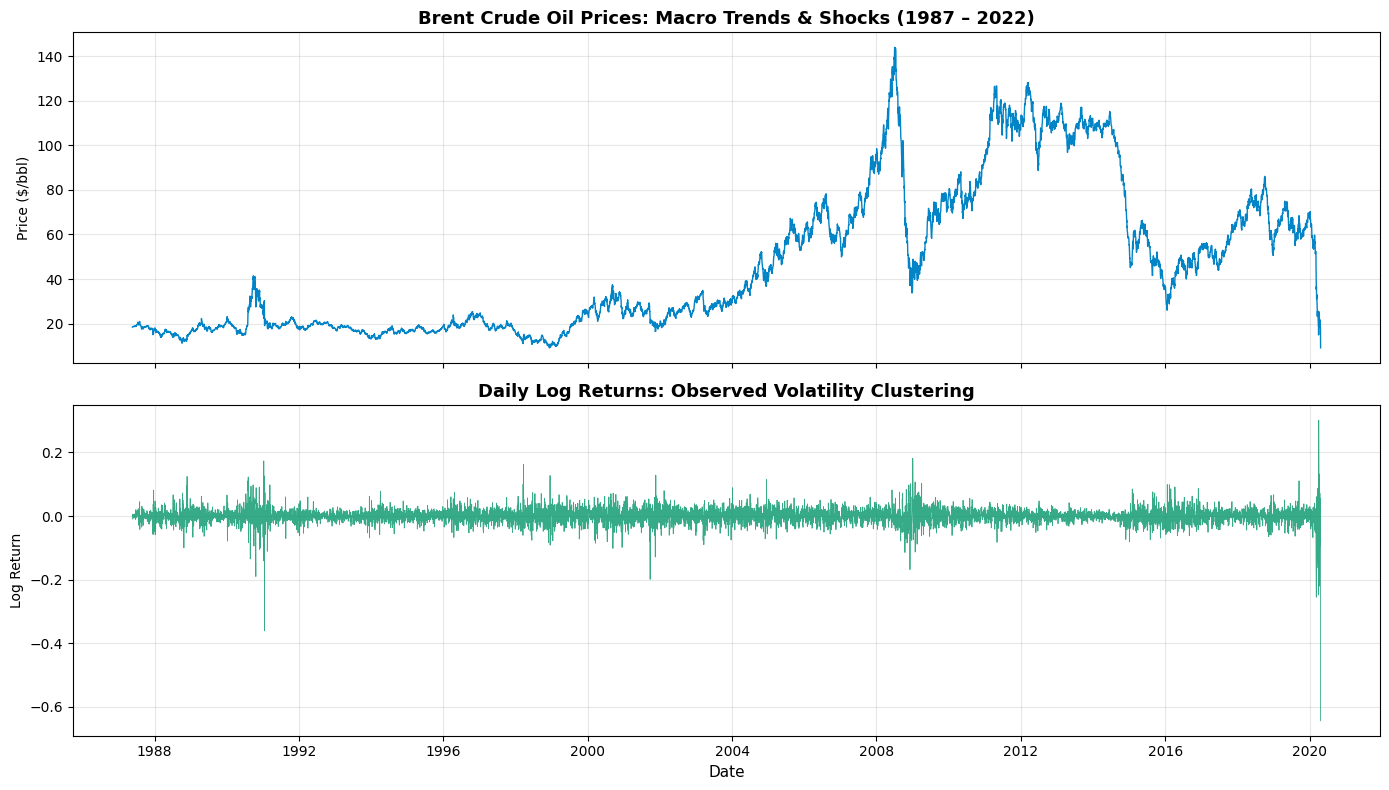

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. LOAD AND PREPROCESS BRENT OIL PRICE DATASET
# =====================================================================
print("📂 Loading historical Brent oil price dataset...")
DATA_PATH = os.path.join('..', 'data', 'raw', 'BrentOilPrices.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/raw/BrentOilPrices.csv"  # Local fallback check

df = pd.read_csv(DATA_PATH)
df.columns = [col.strip() for col in df.columns]

# Convert Date to datetime format and Price to numeric
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y', errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Sort chronologically and drop missing values
df = df.dropna().sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)

# =====================================================================
# 2. COMPUTE LOG RETURNS FOR STATIONARITY
# =====================================================================
# Formula: log(price_t) - log(price_{t-1})
df['Log_Return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
df_clean = df.dropna()

print(f"✅ Data processed successfully. Total records: {len(df_clean)}")

# =====================================================================
# 3. PLOT RAW PRICE AND LOG RETURNS
# =====================================================================
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True)

# Plot raw Price series over time
axes[0].plot(df_clean.index, df_clean['Price'], color='#0284c7', linewidth=1)
axes[0].set_title("Brent Crude Oil Prices: Macro Trends & Shocks (1987 – 2022)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Price ($/bbl)", fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot log returns to observe volatility clustering
axes[1].plot(df_clean.index, df_clean['Log_Return'], color='#059669', linewidth=0.6, alpha=0.8)
axes[1].set_title("Daily Log Returns: Observed Volatility Clustering", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Log Return", fontsize=10)
axes[1].set_xlabel("Date", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
import os
os.environ['PYTENSOR_FLAGS'] = 'cxx='

import pymc as pm
import numpy as np

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [ ]:
import os
import pandas as pd
import numpy as np
import pymc as pm

# 1. Load and prep cleaned data
DATA_PATH = os.path.join('..', 'data', 'raw', 'BrentOilPrices.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/raw/BrentOilPrices.csv"

df = pd.read_csv(DATA_PATH)
df.columns = [col.strip() for col in df.columns]
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y', errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df_clean = df.dropna().sort_values('Date').reset_index(drop=True)

# Extract price array and time index
y = df_clean['Price'].values
n_data = len(y)
time_idx = np.arange(n_data)

print(f"⚙️ Building Gaussian change point model in PyMC for {n_data} observations...")

with pm.Model() as brent_cp_model:
    # 2. Define the Switch Point (tau) as a discrete uniform prior over all possible days
    tau = pm.DiscreteUniform('tau', lower=0, upper=n_data - 1)
    
    # 3. Define "Before" and "After" parameters (mu_1, mu_2) for the mean shift
    mu_1 = pm.Normal('mu_1', mu=y.mean(), sigma=y.std() * 2)
    mu_2 = pm.Normal('mu_2', mu=y.mean(), sigma=y.std() * 2)
    
    # Define observational volatility prior
    sigma = pm.HalfNormal('sigma', sigma=y.std())
    
    # 4. Use a Switch Function (pm.math.switch) to select the correct parameter based on time index vs tau
    mu_t = pm.math.switch(time_idx < tau, mu_1, mu_2)
    
    # 5. Define the Likelihood connecting the Normal distribution to the data
    likelihood = pm.Normal('likelihood', mu=mu_t, sigma=sigma, observed=y)
    
    # 6. Run the Sampler: Execute MCMC simulation via pm.sample()
    print("🚀 Running MCMC simulation...")
    trace = pm.sample(draws=1000, tune=1000, return_inferencedata=True, target_accept=0.9)

print("✅ MCMC sampling finished successfully.")

⚙️ Building Gaussian change point model in PyMC for 8360 observations...
🚀 Running MCMC simulation...


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\rich\live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')